# Demonstrating `uncertainty` module

In this notebook we show the how to use and apply the classess and method in the sub modules of the `uncertainty` module this include:
- Importing uncertainty information
- Filtering uncertain parameters
- selecting and changing probability distribution information of uncertain parameters

In [40]:
%load_ext autoreload
%autoreload 2
import os
import sys
import pandas as pd
sys.path.append('..')
from pulpo import pulpo
from pulpo.utils.uncertainty import preparer, processor, plots, gsa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Defining the underlying case study

In [60]:
from typing import Union, List, Optional, Dict, Tuple

class BaseCaseStudy:
    """
    Abstract base class for a PULPO‐based LCA case study.

    Attributes:
        project (str): PULPO project name.
        database (str or list of str): Name(s) of the inventory database.
        method (str, list, or dict): LCIA method specification.
        directory (str): Working directory for inputs/outputs.
        pulpo_worker (pulpo.PulpoOptimizer): Solver instance, created by create_pulpo_worker.
        demand (dict): Functional unit demands (process → amount).
        choices (dict): Choices (process → capacity) in the model.
    """

    def __init__(self, project:str, database: Union[str, List[str]], method:Union[str, List[str], dict], directory :str ):
        """
        Initialize the case study with project, database, method, and directory.

        Args:
            project: Name of the PULPO project.
            database: Inventory database(s) to load.
            method: LCIA method(s) to apply.
            directory: Path to working directory for saving results.
        """
        self.project = project
        self.database = database
        self.method = method
        self.directory = directory
        self.demand:dict = {}
        self.choices:dict = {}

    def create_pulpo_worker(self):
        """
        Instantiate a PulpoOptimizer and import LCI data.

        Creates `self.pulpo_worker` and calls its get_lci_data() to load
        life cycle inventory matrices and metadata.
        """
        # Create a **PulpoOptimizer** instance. This class is used to interact with the LCI database and solve the optimization problem. It is specified by the project, database, method and directory.
        self.pulpo_worker = pulpo.PulpoOptimizer(self.project, self.database, self.method, self.directory)
        # Import LCI data. After initializing the PulpoOptimizer instance, the LCI data is imported from the database.
        self.pulpo_worker.get_lci_data()

    def solve_and_summarize(self, file_name) -> dict:
        """
        Solve the optimization model and summarize results.

        Args:
            file_name: Filename for saving results (ignored if saver used directly).

        Returns:
            result_data (dict): Extracted results dictionary.
        """

        # Instantiat and solve the optimization model
        # self.pulpo_worker.solve()
        # options = {'NEOS_EMAIL':'b.j.p.m.haussling.lowgren@cml.leidenuniv.nl'}
        # self.pulpo_worker.solve(solver_name='cplex', options=options)
        self.pulpo_worker.solve()
        # Save and summarize the results
        result_data = self.pulpo_worker.extract_results()
        self.pulpo_worker.summarize_results(zeroes=True)
        # self.pulpo_worker.save_results(result_data, file_name) # ATTN: This still does not work with the saver code probably still a mistake in there
        return result_data
    
class AmmoniaCase(BaseCaseStudy):
    """
    Case study for the reducts Ammonia case study.

    Defines the functional unit, choice sets, and instantiates the PULPO model.
    """
    def __init__(self):
        """
        Set up default project, database, method, and directory
        for the Ammonia case study.
        """
        self.project = "ammonia_reduced"
        self.database = ["ecoinvent-3.10-cutoff", "ammonia-reduced"]
        self.method = "('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')"
        self.directory = os.path.join(os.path.dirname(os.getcwd()), 'develop_tests/data')

    def create_pulpo_worker(self):
        """
        Instantiate a PulpoOptimizer and import LCI data.

        Creates `self.pulpo_worker` and calls its get_lci_data() to load
        life cycle inventory matrices and metadata.
        """
        # Create a **PulpoOptimizer** instance. This class is used to interact with the LCI database and solve the optimization problem. It is specified by the project, database, method and directory.
        self.pulpo_worker = pulpo.PulpoOptimizer(self.project, self.database, self.method, self.directory)
        self.pulpo_worker.intervention_matrix="ecoinvent-3.10-biosphere"
        # Import LCI data. After initializing the PulpoOptimizer instance, the LCI data is imported from the database.
        self.pulpo_worker.get_lci_data()

    def define_problem(self):
        """
        Specify the functional unit, define choice options and capacities,
        and instantiate the PULPO model with self.pulpo_worker.instantiate().
        """
        
        choices_biomethane_CS = ["biogas upgrading to biomethane, chemical scrubbing"]
        choices_biomethane_CSwCCS = ["biogas upgrading to biomethane, chemical scrubbing w/ CCS"]
        choices_biomethane_WS = ["biogas upgrading to biomethane, water scrubbing"]
        choices_biomethane_WSwCCS = ["biogas upgrading to biomethane, water scrubbing w/ CCS"]

        choices_methane_market = [
            "market for bio methane",
            "market group for natural gas, high pressure"
        ]

        choices_hydrogen_SMR = ["hydrogen production, steam methane reforming fg"]
        choices_hydrogen_SMRwCCS = ["hydrogen production, steam methane reforming, w/ CCS"]
        choices_hydrogen_PEM = ["hydrogen production, PEM electrolysis, yellow"]
        choices_hydrogen_plastic = ["hydrogen production, plastics gasification"]
        choices_hydrogen_plasticCCS = ["hydrogen production, plastics gasification, w/ CCS"]

        choices_hydrogen_market = [
            "market for hydrogen",
            "market for hydrogen, gaseous, low pressure"
        ]

        choices_heat_H2 = ["heat from hydrogen"]
        choices_heat_CH4wCCS = ["heat from methane, w/ CCS"]
        choices_heat_CH4 = ["heat from methane"]

        choices_ammonia = [
            "ammonia production, steam methane reforming",
            # "ammonia production, steam methane reforming, w/ CCS",
            "ammonia production, from nitrogen and hydrogen"
        ]

        choices_ammonia_market = [
            "market for ammonia",
            "market for ammonia, anhydrous, liquid"
        ]

        # Retrieve activities for each category and assign to appropriately named variables
        # Retrieve activities for each category and assign to appropriately named variables
        # Biomethane upgrading
        biomethane_activities_CS = self.pulpo_worker.retrieve_activities(activities=choices_biomethane_CS, locations=["RER", "Europe without Switzerland"])
        biomethane_activities_CSwCCS = self.pulpo_worker.retrieve_activities(activities=choices_biomethane_CSwCCS, locations=["RER", "Europe without Switzerland"])
        biomethane_activities_WS = self.pulpo_worker.retrieve_activities(activities=choices_biomethane_WS, locations=["RER", "Europe without Switzerland"])
        biomethane_activities_WSwCCS = self.pulpo_worker.retrieve_activities(activities=choices_biomethane_WSwCCS, locations=["RER", "Europe without Switzerland"])

        methane_market_activities = self.pulpo_worker.retrieve_activities(activities=choices_methane_market, locations=["RER", "Europe without Switzerland"])
        # Hydrogen
        hydrogen_activities_PEM = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_PEM, locations=["RER", "Europe without Switzerland"])
        hydrogen_activities_plastic = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_plastic, locations=["RER", "Europe without Switzerland"])
        hydrogen_activities_plasticCCS = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_plasticCCS, locations=["RER", "Europe without Switzerland"])
        hydrogen_activities_SMR = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_SMR, locations=["RER", "Europe without Switzerland"])
        hydrogen_activities_SMRwCCS = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_SMRwCCS, locations=["RER", "Europe without Switzerland"])
        hydrogen_market_activities = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_market, locations=["RER", "Europe without Switzerland"])
        # Heat
        heat_activities_CH4 = self.pulpo_worker.retrieve_activities(activities=choices_heat_CH4, locations=["RER", "Europe without Switzerland"])
        heat_activities_CH4wCCS = self.pulpo_worker.retrieve_activities(activities=choices_heat_CH4wCCS, locations=["RER", "Europe without Switzerland"])
        heat_activities_H2 = self.pulpo_worker.retrieve_activities(activities=choices_heat_H2, locations=["RER", "Europe without Switzerland"])
        # Ammonia
        ammonia_activities = self.pulpo_worker.retrieve_activities(activities=choices_ammonia, locations=["RER", "Europe without Switzerland"])
        ammonia_market_activities = self.pulpo_worker.retrieve_activities(activities=choices_ammonia_market, locations=["RER", "Europe without Switzerland"])
        
        # Set the demand and other global parameters for the problem definition
        demand_value = 3000e6 
        manure_biogas = 1.8e9 # Setting the manure biomgas availability for 2030
        scale_by_demand = False
        if scale_by_demand:
            scaling_value = demand_value
        else:
            scaling_value = 1

        # Choices as constraints
        self.choices = {
            "ammonia": {x: 1e20 for x in ammonia_activities},
            "methane_market": {x: 1e20 for x in methane_market_activities},
            "hydrogen_market": {x: 1e20 for x in hydrogen_market_activities},
            "ammonia_market": {x: 1e20 for x in ammonia_market_activities},
        }
        self.choices["hydrogen"] = {
            hydrogen_activities_PEM[0] : .3*.1e9/scaling_value, # 0.1 Mt H2 -- 30% of PEM to NH3
            hydrogen_activities_SMR[0] : 1e20, # SMR
            hydrogen_activities_SMRwCCS[0] : .3*.5e9/scaling_value, # 0.5 Mt H2 -- 30% of SMR w CCS H2 for NH3
            hydrogen_activities_plastic[0] : .3*40e6/scaling_value, # 40 kt H2 -- 30% of plastic gasification for NH3
            hydrogen_activities_plasticCCS[0] : .3*1e6/scaling_value, # 10 kt H2 -- 30% of plastic gasification w CCS for NH3
        }
        self.choices["heat"] = {
            heat_activities_CH4[0]: 1e20,
            heat_activities_CH4wCCS[0]: .1*1.4e10/scaling_value, # Assuming 10% of the heat currently needed for Ammonia produciton
            heat_activities_H2[0]:1*1.4e10/scaling_value, # Assuming 10% of the heat currently needed for Ammonia produciton
        }
        self.choices["biomethane"] = {
            biomethane_activities_CS[0]: 1e20, # Assumingly the same potential as WS
            biomethane_activities_CSwCCS[0]: .1*.2*manure_biogas/scaling_value, # Guess: the same as WS wCCS
            biomethane_activities_WS[0]: 1e20, # Assumingly the base case technology
            biomethane_activities_WSwCCS[0]: .1*.2*manure_biogas/scaling_value #  20% (biomethane for NH3) of 10% (CCS for biomethane )of 1.8 mt (biomethane) for which is the max capacity 2030
        }
        
        # Additional constraints
        anaerobic_digestion = self.pulpo_worker.retrieve_activities(activities='anaerobic digestion of animal manure, with biogenic carbon uptake', locations=["RER", "Europe without Switzerland"])
        upper_bound = {
            anaerobic_digestion[0]:.2*1.8e9/scaling_value # 20% of 1.8 mt which is the max capacity 2030
            } 

        # Demand
        ammonia_market = self.pulpo_worker.retrieve_activities(activities="market for ammonia")
        self.demand = {"ammonia_market": demand_value/scaling_value} # Ammonia production capacity Germany
        
        # Instantiate the pulpo instance
        self.pulpo_worker.instantiate(choices=self.choices, demand=self.demand, upper_limit=upper_bound)



In [5]:
case_study = AmmoniaCase()
case_study.create_pulpo_worker()
case_study.define_problem()
result_data = case_study.solve_and_summarize(file_name='ammonia_test')


Creating Instance
Instance created
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47102 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47102 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23537 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23549 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  3881518178.900435


## Total Impact(s)

,Weight,Value
Method,,
"('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')",1,3.881518e+09


## Choices Made

### ammonia

...

### biomethane

,Value,Capacity
Metadata,,
"biogas upgrading to biomethane, chemical scrubbing | biomethane, 24 bar | RER",1.351234e+08,1.000000e+20
"biogas upgrading to biomethane, chemical scrubbing w/ CCS | biomethane, 24 bar | RER",3.600000e+07,3.600000e+07
"biogas upgrading to biomethane, water scrubbing w/ CCS | biomethane, 24 bar | RER",3.600000e+07,3.600000e+07


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
23532,"(ammonia-reduced, a2610a42cd93afb46b13b2e95273...","anaerobic digestion of animal manure, with bio...",360000000.0,360000000.0


## 2. Filtering out negletable uncertain parameters

We only consider uncertainty in the $B$ and $Q$ parameter matrizes. The scaling vector is given by the optimal solution.

The parameter filter, aims to reduce the set of uncertain parameters to reduce the computational effort for the GSA or for CC optimization. 

There is however an inherent risk when reducing the set of parameters before using chance constraint optimization, since relevant uncertain parameters at the non deterministic solution might be filtered out, which can be significant at higher probability levels.

In [61]:
paramfilter = preparer.ParameterFilter(
    lci_data=case_study.pulpo_worker.lci_data, 
    choices = case_study.choices,
    demand = case_study.demand,
    method = case_study.method
    )

Using the basic scaling vector which only includes the optimal choices in the scaling vector

In [64]:
scaling_vector_series = paramfilter.prepare_scaling_vector(scaling_vector_strategy='naive', result_data=result_data)

Using the scaling vector constructed from all choices

In [66]:
scaling_vector_series = paramfilter.prepare_scaling_vector(scaling_vector_strategy='constructed_demand')

Compute the LCA scores and return the characterized inventory to be used for the filtering

In [67]:
lca_score, characterized_inventory = paramfilter.compute_LCI_LCIA(scaling_vector_series)

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: 5.426719e+01


Plot the largest contributors

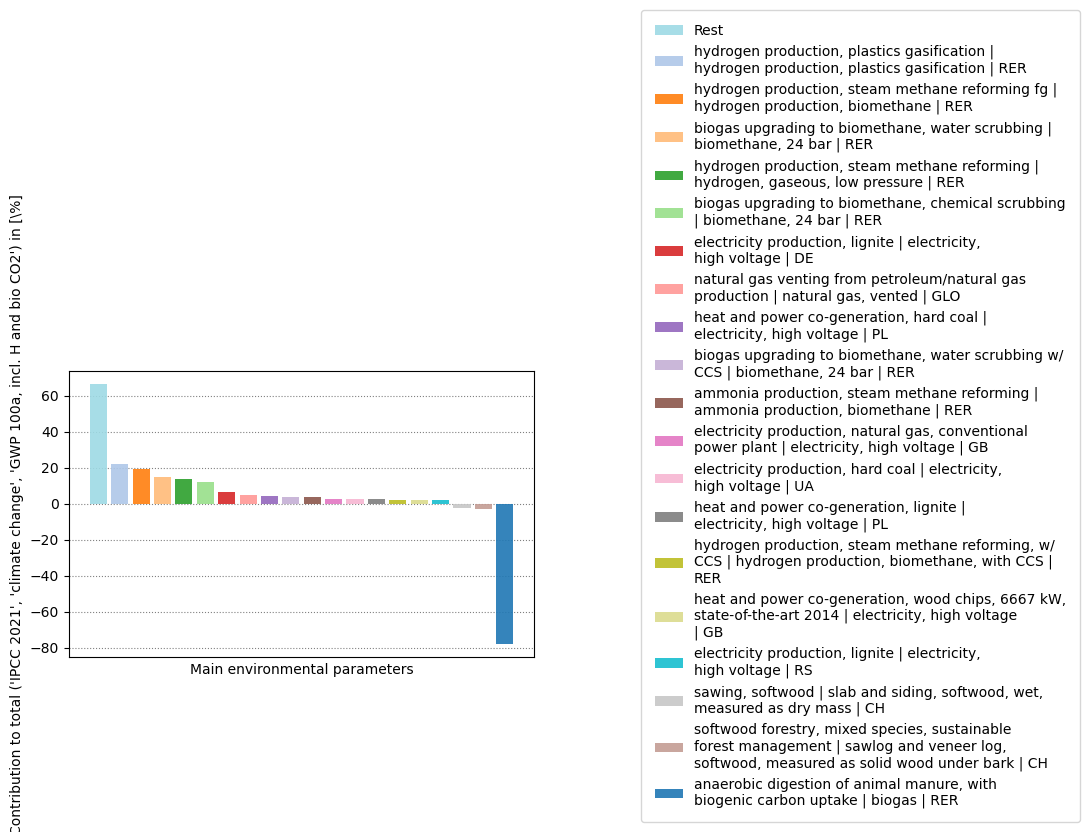

In [68]:
plots.plot_top_characterized_processes(case_study.pulpo_worker.lci_data['process_map_metadata'], characterized_inventory, case_study.method, top_amount=19)

Filtering out the inventoryflows $B_{i,j}$ that have a neglectable impact

In [69]:
cutoff = 0.000019 # ATTN: Change to 0. to include all parameters, this is needed to include the CCS biosphere flows else they are filtered out
# cutoff = 0.
filtered_inventory_indcs = paramfilter.filter_inventoryflows(characterized_inventory, lca_score, cutoff)

Characterized inventory: (2648, 23557) 26581
Filtered characterized inventory: (2648, 23557) 1009
Deviation from LCA score: 0.009507277234347966
inventory (2648, 23557) filtering resulted in 1009 of 26581 exchanges (99.05% of total impact) and took 0.005 seconds.


In [70]:
filtered_characterization_indcs = paramfilter.filter_characterization_factors(filtered_inventory_indcs)

CHARACTERIZATION MATRIX (2648,) filtering resulted in 27 of 111 characterization factors


Alternativly all the methods can be called with the `apply_filter` method.

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: 5.426719e+01


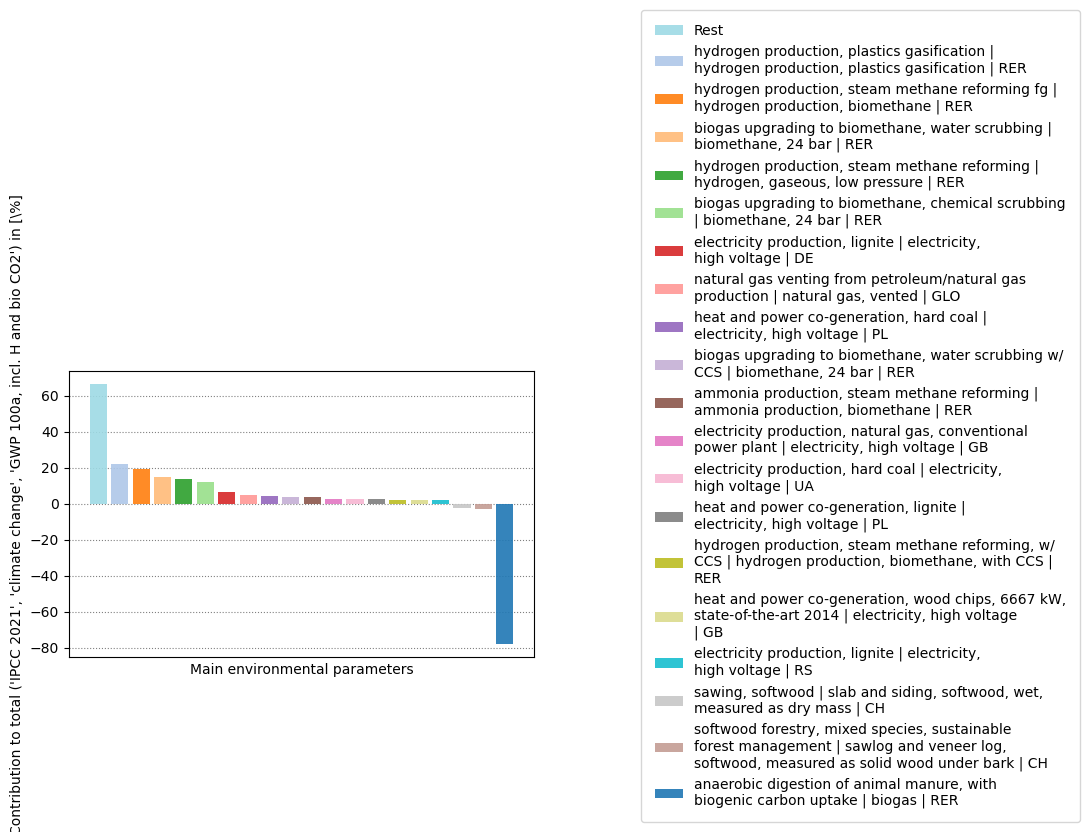

Characterized inventory: (2648, 23557) 26581
Filtered characterized inventory: (2648, 23557) 177
Deviation from LCA score: 0.12532326402220306
inventory (2648, 23557) filtering resulted in 177 of 26581 exchanges (87.47% of total impact) and took 0.003 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 11 of 111 characterization factors


In [72]:
filtered_inventory_indcs, filtered_characterization_indcs = paramfilter.apply_filter(
    scaling_vector_strategy='constructed_demand',
    cutoff=0.001,
    plot_results=True,
    plot_n_top_processes=19
)

## 3. Getting the uncertainty of the parameter values

The uncertainty data can be filtered and imported and strategies applied directly with the pulpo worker, shown below. In the following subsections the method called in the pulpo worker wrapper methods are shown and explained

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: 5.426719e+01


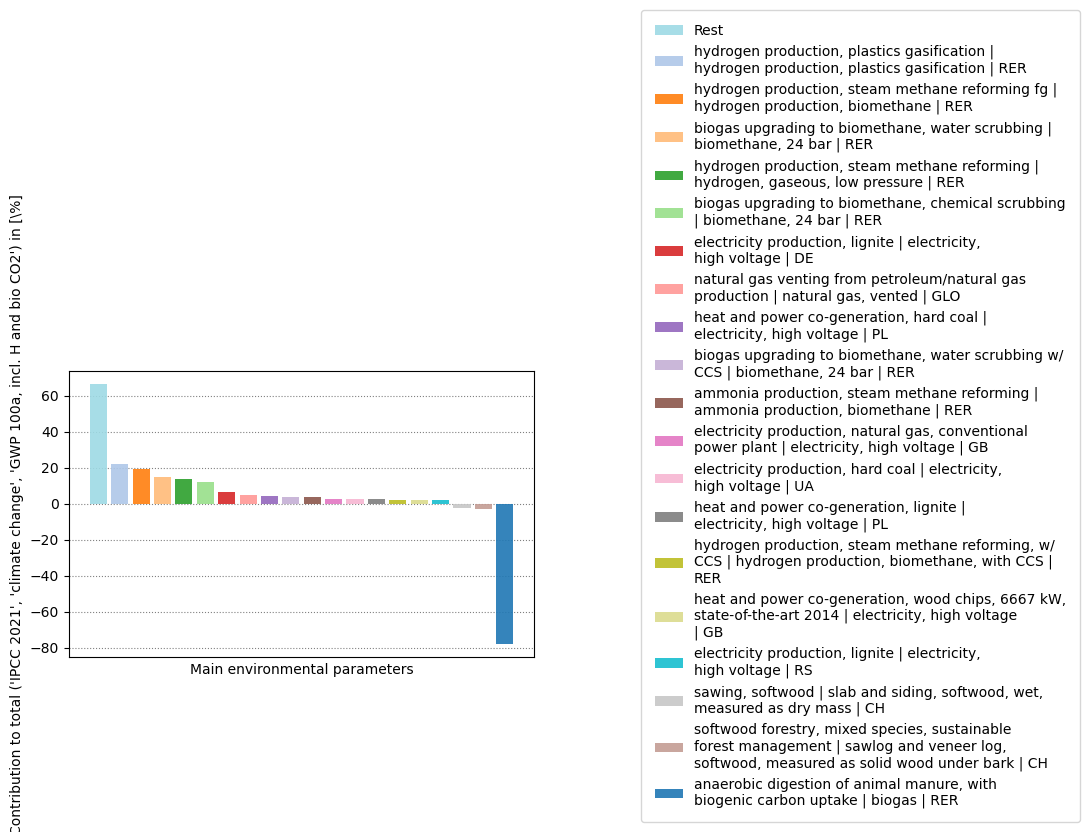

Characterized inventory: (2648, 23557) 26581
Filtered characterized inventory: (2648, 23557) 1009
Deviation from LCA score: 0.009507277234347966
inventory (2648, 23557) filtering resulted in 1009 of 26581 exchanges (99.05% of total impact) and took 0.002 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 27 of 111 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 886 
Parameters without uncertainty information: 96
In ammonia-reduced:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 27
Charactetization factors:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 27
Variable bounds:
Upper bound from choices without uncertainty information: 20
Upper bound from `upper_limit` without uncertainty information: 1
Lower bound from `lower_limit` without uncertainty information: 0


In [78]:
case_study.pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=0.000019,
    scaling_vector_strategy='constructed_demand',
    plot_results=True,
    plot_n_top_processes=19
)

The uncertainty strategies can be directly performed on the pulpo worker if the strategies are passed to the pulpo worker, else a standard trigional distribution is used

In [88]:
# TEST THIS AS THE NEXT STEP!!
case_study.pulpo_worker.apply_uncertainty_strategies()

Applying default uncertainty strategies.
Creating base case uncertainty strategies for intervention flows
	Creating triangular bound interpolation strategy for intervention flows in database: ecoinvent-3.10-cutoff


ZeroDivisionError: division by zero

### 3.1. Importing the uncertainty data

Imports uncertainty data for the intervention flows and the characterization factors from the databases and Brightway project. It also creates uncertainty data (with unspecified distributions) for the variables bounds specified for the pulpo instance.

Extracts the metadata containing the uncertainty information to the filtered intervention flows and seperate the metadata into the parameters with and without defined uncertainty information

In [33]:
uncertainty_importer = preparer.UncertaintyImporter(
    lci_data=case_study.pulpo_worker.lci_data, 
    bw_databases=case_study.database, 
    LCIA_method=case_study.method,
)
uncertainty_data = uncertainty_importer.import_uncertainty_data(
    if_indcs=filtered_inventory_indcs,
    cf_indcs=filtered_characterization_indcs,
    choices=case_study.pulpo_worker.choices,
    upper_limit=case_study.pulpo_worker.upper_limit,
    lower_limit=case_study.pulpo_worker.lower_limit,
    upper_elem_limit=case_study.pulpo_worker.upper_elem_limit,
    upper_imp_limit=case_study.pulpo_worker.upper_imp_limit,
)

Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 134 
Parameters without uncertainty information: 25
In ammonia-reduced:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 18
Charactetization factors:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 11
Variable bounds:
Upper bound from choices without uncertainty information: 20
Upper bound from `upper_limit` without uncertainty information: 1
Lower bound from `lower_limit` without uncertainty information: 0


### 3.2. Apply strategies to define missing uncertainty data

#### 3.2.1. Intervention flows

In [34]:
print(case_study.database)

['ecoinvent-3.10-cutoff', 'ammonia-reduced']


Apply the triangular strategy using bound interpolation to the missing intervention uncertainty parameters in the background database

In [35]:
if_bg_triangular_strategy = processor.TriangularBoundInterpolationStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ecoinvent-3.10-cutoff',
    noise_interval={'min':.1, 'max':.1}
    )
if_bg_triangular_strategy.assign(uncertainty_data)

upper spread statistics
mean: 0.5762
mode: 0    0.438093
dtype: float64
median: 0.4918
std: 0.7305
min: 0.0582
max: 4.0573


lower spread statistics
mean: 0.3080
mode: 0    0.304635
dtype: float64
median: 0.3297
std: 0.1422
min: 0.0550
max: 0.8023

The upper spread scaling factor for intervention flows is: 0.49182484911329366
The lower spread scaling factor for intervention flows is: 0.32967994411934776


Apply the Uniform strategy for the uncertainty parameters in the foreground database

In [36]:
if_fg_uniform_strategy = processor.UniformBaseStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ammonia-reduced',
    upper_scaling_factor = .5,
    lower_scaling_factor = .5,
    noise_interval={'min':.2, 'max':.2}
)
if_fg_uniform_strategy.assign(uncertainty_data)

Set expert judgement uncertainties to a few selected intervention flows:

In [89]:
# ATTN: It might be better to not call an index directly but search for the process and the intervention flow, just not sure how
# This can be done in a step before which returns the indices and can be called like defined here
CCS_expert_uncertainty_info = {
    (80, 23548): {'minimum':.01 ,'maximum':.5, 'uncertainty_type':4}, # carbon dioxide storage and transport 200 km pipeline, storage 1000 m | carbon dioxide storage and transport 200 km pipeline, storage 1000 m | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    (80, 23538): {'minimum':.0002 ,'maximum':.002, 'uncertainty_type':4}, # transport, pipeline, supercritical carbon dioxide, 200 km without recompression | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    }
if_fg_expert_knowledge_strategy = processor.ExpertKnowledgeStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ammonia-reduced',
    prob_metadata=CCS_expert_uncertainty_info
)
if_fg_expert_knowledge_strategy.assign(uncertainty_data)

Check if the uncertainty data has been assgined correctly to the flows

In [90]:
processor.rename_metadata_index(
    pd.DataFrame.from_records(uncertainty_data['If']['ammonia-reduced']['defined'])[list(CCS_expert_uncertainty_info.keys())].T, 
    case_study.pulpo_worker.lci_data, 
    'intervention_flow'
    )


,index,input,output,type,uncertainty_type,amount,loc,scale,shape,minimum,maximum,negative
"carbon dioxide storage and transport 200 km pipeline, storage 1000 m | carbon dioxide storage and transport 200 km pipeline, storage 1000 m | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')","(80, 23548)",107,28128,2,4,0.01,NaN,NaN,NaN,0.01,0.5,False
"transport, pipeline, supercritical carbon dioxide, 200 km without recompression | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')","(80, 23538)",107,28117,2,4,0.00026,NaN,NaN,NaN,0.0002,0.002,False


#### 3.2.2. Characterization factors

Apply the triangular strategy using predefined scaling factors to the missing uncertainty parameters

In [37]:
cf_triangular_strategy = processor.TriangluarBaseStrategy(
    uncertain_param_type='Cf',
    uncertain_param_subgroup=case_study.method,
    upper_scaling_factor = 0.15,
    lower_scaling_factor = 0.15,
    noise_interval={'min':.1, 'max':.1}
)
cf_triangular_strategy.assign(uncertainty_data)

#### 3.2.3. Variable bounds

Defining the uncertainty information for the variable bounds

Apply triangular uncertainty strategy with upper and lower scaling factor to the variable bounds (any other strategy is also possible)

In [38]:
var_bound_upper_strategy = processor.TriangluarBaseStrategy(
    uncertain_param_type='Var_bounds',
    uncertain_param_subgroup='upper_limit',
    upper_scaling_factor=.3,
    lower_scaling_factor=.3,
    noise_interval={'min':.2, 'max':.1}
)
var_bound_upper_strategy.assign(uncertainty_data)

#### 3.2.4. All at once

The strategies can all be applied at once if they are passed to the `apply_uncertainty_strategies` method.

In the future this can also easily be rewritten to pass a json file or dict containing the set up for each uncertainty strategy

In [32]:
processor.apply_uncertainty_strategies(
    uncertainty_data,
    processor.TriangularBoundInterpolationStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ecoinvent-3.10-cutoff',
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.UniformBaseStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia-reduced',
        upper_scaling_factor = .5,
        lower_scaling_factor = .5,
        noise_interval={'min':.2, 'max':.2}
    ),
    processor.ExpertKnowledgeStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia-reduced',
        prob_metadata={
            (80, 23548): {'minimum':.01 ,'maximum':.5, 'uncertainty_type':4}, # carbon dioxide storage and transport 200 km pipeline, storage 1000 m | carbon dioxide storage and transport 200 km pipeline, storage 1000 m | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
            (80, 23538): {'minimum':.0002 ,'maximum':.002, 'uncertainty_type':4}, # transport, pipeline, supercritical carbon dioxide, 200 km without recompression | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
        }
    ),
    processor.TriangluarBaseStrategy(
        uncertain_param_type='Cf',
        uncertain_param_subgroup=case_study.method,
        upper_scaling_factor = 0.15,
        lower_scaling_factor = 0.15,
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.TriangluarBaseStrategy(
        uncertain_param_type='Var_bounds',
        uncertain_param_subgroup='upper_limit',
        upper_scaling_factor=.3,
        lower_scaling_factor=.3,
        noise_interval={'min':.2, 'max':.1}
    )
)

upper spread statistics
mean: 0.5762
mode: 0    0.438093
dtype: float64
median: 0.4918
std: 0.7305
min: 0.0582
max: 4.0573


lower spread statistics
mean: 0.3080
mode: 0    0.304635
dtype: float64
median: 0.3297
std: 0.1422
min: 0.0550
max: 0.8023

The upper spread scaling factor for intervention flows is: 0.49182484911329366
The lower spread scaling factor for intervention flows is: 0.32967994411934776


Exception: (80, 23538) is not found in "defined" uncertainty data of ammonia-reduced in If.

## 4. Define the global sensitivity problem

In [79]:
from SALib.sample import sobol as sample_method
from SALib.analyze import sobol as SA_method

The global sensitivity analysis can be called directly from the pulpo worker

In [83]:
case_study.pulpo_worker.run_gsa(
    result_data=result_data,
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=True
)

If - ecoinvent-3.10-cutoff 
 	 96 parameters without uncertainty information
If - ammonia-reduced 
 	 27 parameters without uncertainty information
Cf - ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2') 
 	 27 parameters without uncertainty information
Var_bounds - upper_limit 
 	 21 parameters without uncertainty information


Exception: The uncertainty data contains undefined uncertainty types. Please define all uncertainty types before running the GSA.

### 4.1. Define the bound/interval of the parameters

Check if all parameters have gotten uncertainty information asigned

In [ ]:

N = 100

gsa_study = gsa.GlobalSensitivityAnalysis(
    result_data=result_data,
    lci_data=case_study.pulpo_worker.lci_data,
    uncertainty_data=uncertainty_data,
    sampler=sample_method,
    analyser=SA_method,
    sample_size=N,
    method=case_study.method
)
gsa_problem, all_bounds_indx_dict = gsa_study.define_problem()

problem includes:
177 uncertain intervention flows
11 uncertain characterization factors


In [51]:
sample_data_if, sample_data_cf = gsa_study.sample(gsa_problem, all_bounds_indx_dict)

/Users/hausslingbhl/miniconda3/envs/pulpo_dev/lib/python3.10/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


The statistics of the the sample impacts: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
count    3.780000e+04
mean     3.988879e+09
std      4.456561e+08
min      2.518071e+09
25%      3.672632e+09
50%      4.003139e+09
75%      4.290365e+09
max      5.403953e+09
dtype: float64
The deterministic impact is 1.0 : 3.881518e+09
(37800,)
the z-value of the total impact: 0.1117246581471781


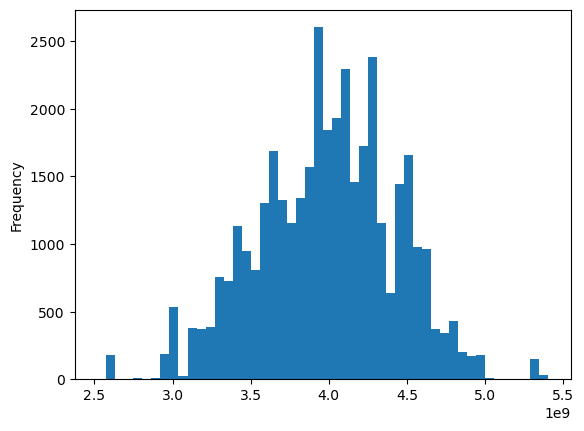

In [52]:
sample_impacts, sample_characterized_inventories = gsa_study.run_model(sample_data_if, sample_data_cf)

In [56]:
total_Si, _ = gsa_study.analyze(gsa_problem, sample_impacts)

/Users/hausslingbhl/miniconda3/envs/pulpo_dev/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


The total explained variance is 
101.9%


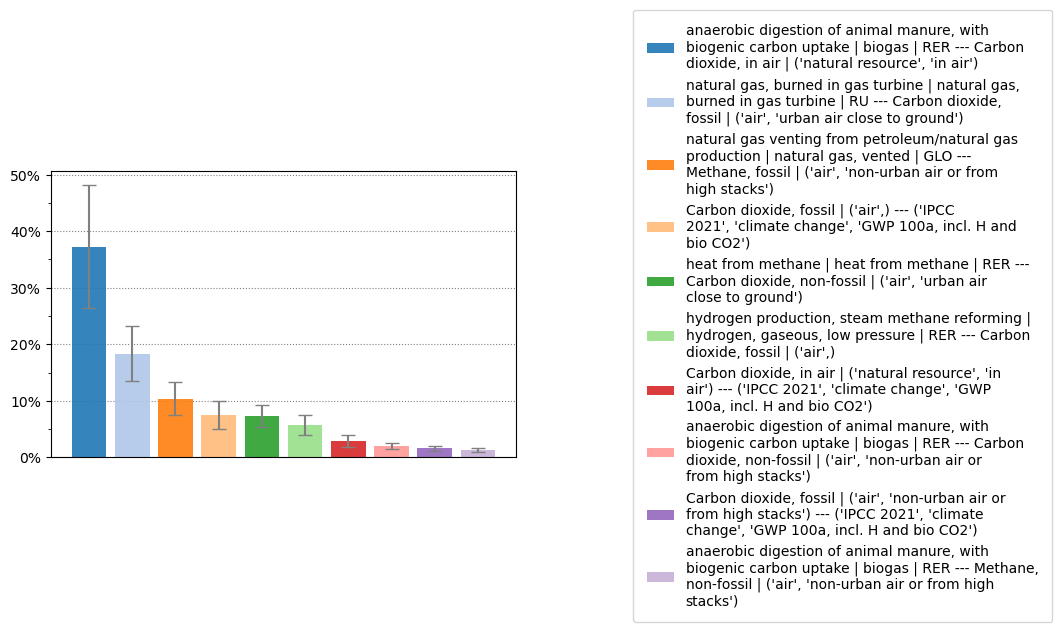

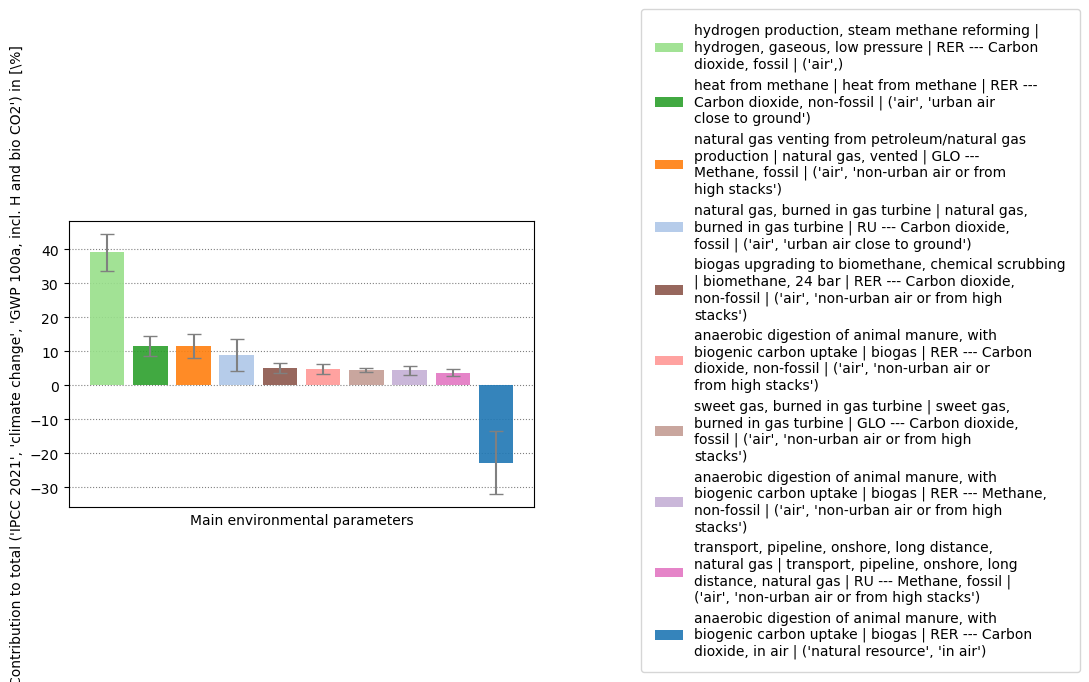

In [58]:
gsa_study.plot_gsa_results(all_bounds_indx_dict, total_Si, sample_characterized_inventories)

Alternativly call the the `perform_gsa` method to perform the full gsa at once

problem includes:
177 uncertain intervention flows
11 uncertain characterization factors


/Users/hausslingbhl/miniconda3/envs/pulpo_dev/lib/python3.10/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


The statistics of the the sample impacts: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
count    3.780000e+04
mean     3.989346e+09
std      4.394081e+08
min      2.663970e+09
25%      3.695008e+09
50%      4.010982e+09
75%      4.274905e+09
max      5.445208e+09
dtype: float64
The deterministic impact is 1.0 : 3.881518e+09
(37800,)
the z-value of the total impact: 0.110145394814481


/Users/hausslingbhl/miniconda3/envs/pulpo_dev/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


The total explained variance is 
105.6%


(                      ST       ST_conf
 (80, 362)   0.000000e+00  0.000000e+00
 (80, 1236)  6.222286e-07  1.906139e-07
 (80, 1839)  1.127119e-05  3.464664e-06
 (80, 2045)  2.323283e-04  6.825190e-05
 (80, 4380)  8.894304e-06  2.740289e-06
 ...                  ...           ...
 718         7.903982e-02  2.233237e-02
 881         1.000599e-03  2.907328e-04
 894         1.162494e-02  4.246819e-03
 2129        1.387954e-05  5.318718e-06
 2515        6.936509e-08  2.038914e-08
 
 [188 rows x 2 columns],
 {'S1': array([ 0.00000000e+00,  1.09627958e-04,  4.96023761e-05,  1.23222632e-03,
         -3.79764110e-05,  1.54140157e-04,  1.06759114e-04, -1.08223006e-07,
         -2.29234244e-05, -1.85107010e-04, -8.70118913e-05,  4.47547510e-05,
         -1.68458942e-04,  1.50611392e-01, -3.80051868e-05,  8.48348595e-04,
         -2.38947327e-06,  1.62724777e-04,  1.37398059e-02,  3.86258051e-04,
          3.39326051e-03,  1.11563303e-02, -7.56650387e-04, -2.26033117e-08,
          3.19843946e-05,

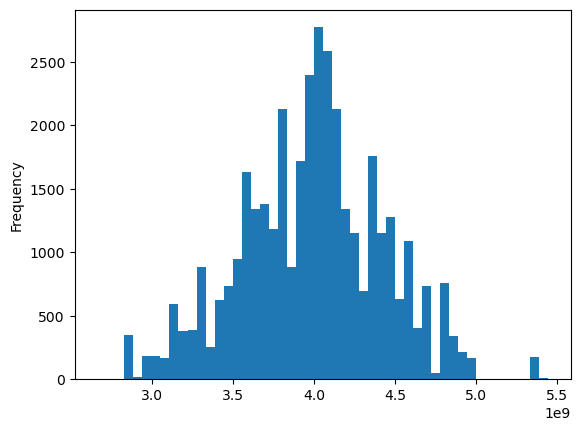

In [59]:
gsa_study.perform_gsa()

In [19]:
All_if_uncertainty_data = {}
for database in uncertainty_data['If'].keys():
    All_if_uncertainty_data.update(uncertainty_data['If'][database]['defined'])